## SETUP


In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
def load_data(p): return pd.read_csv(p)


### Load result to data frame


In [2]:
multi = load_data('multi/result.csv')
tier_cols = ['tier1_syntax', 'tier2a_cc', 'tier2b_boundary', 'tier2c_intent_math', 'tier3_judge']
for c in tier_cols:
    multi[c] = pd.to_numeric(multi[c], errors='coerce').fillna(0)
multi['any_tier'] = (multi[tier_cols].sum(axis=1) > 0)


# RAW Validation Interception — All Entries


Validation Interception Rates (RAW, n=279):
  tier1_syntax         (Syntax      ):   14/279 =   5.0%
  tier2a_cc            (CC          ):   11/279 =   3.9%
  tier2b_boundary      (Boundary    ):   20/279 =   7.2%
  tier2c_intent_math   (Intent Math ):   77/279 =  27.6%
  tier3_judge          (Judge       ):   25/279 =   9.0%
  any_tier             (Any tier    ):  127/279 =  45.5%


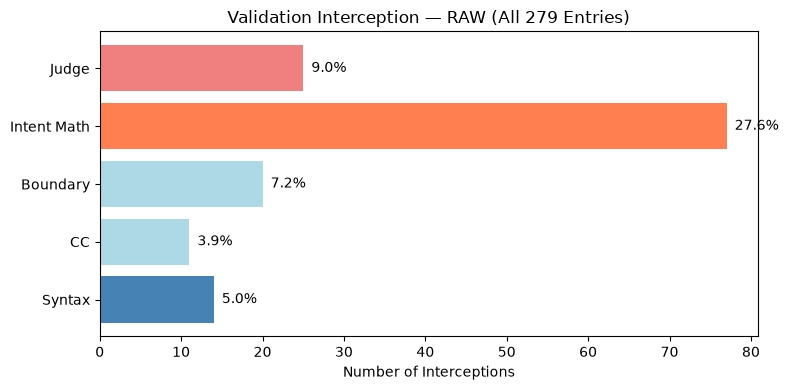

In [3]:
print(f"Validation Interception Rates (RAW, n=279):")
rows = []
tier_short = ['Syntax', 'CC', 'Boundary', 'Intent Math', 'Judge']
for i, c in enumerate(tier_cols):
    cnt = int((multi[c] > 0).sum())
    pct = cnt / len(multi) * 100
    print(f"  {c:20s} ({tier_short[i]:12s}): {cnt:4d}/{len(multi)} = {pct:5.1f}%")
    rows.append([tier_short[i], cnt, round(pct, 1)])
any_cnt = int(multi['any_tier'].sum())
print(f"  {'any_tier':20s} ({'Any tier':12s}): {any_cnt:4d}/{len(multi)} = {any_cnt/len(multi)*100:5.1f}%")

labels = [r[0] for r in rows]
values = [r[1] for r in rows]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, values, color=['steelblue','lightblue','lightblue','coral','lightcoral'])
ax.set_title('Validation Interception — RAW (All 279 Entries)')
for bar, val in zip(bars, [r[2] for r in rows]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')
ax.set_xlabel('Number of Interceptions')
plt.tight_layout()
plt.savefig('charts/tier/tier_interception_overall.png', dpi=100)
plt.show()


#### Validation Interception by Exit Status


SUCCESS (n=198):
  tier1_syntax:    1 (0.5%)
  tier2a_cc:    3 (1.5%)
  tier2b_boundary:    9 (4.5%)
  tier2c_intent_math:   22 (11.1%)
  tier3_judge:   18 (9.1%)
  any_tier:   46 (23.2%)

ABORT_STRATEGY (n=81):
  tier1_syntax:   13 (16.0%)
  tier2a_cc:    8 (9.9%)
  tier2b_boundary:   11 (13.6%)
  tier2c_intent_math:   55 (67.9%)
  tier3_judge:    7 (8.6%)
  any_tier:   81 (100.0%)



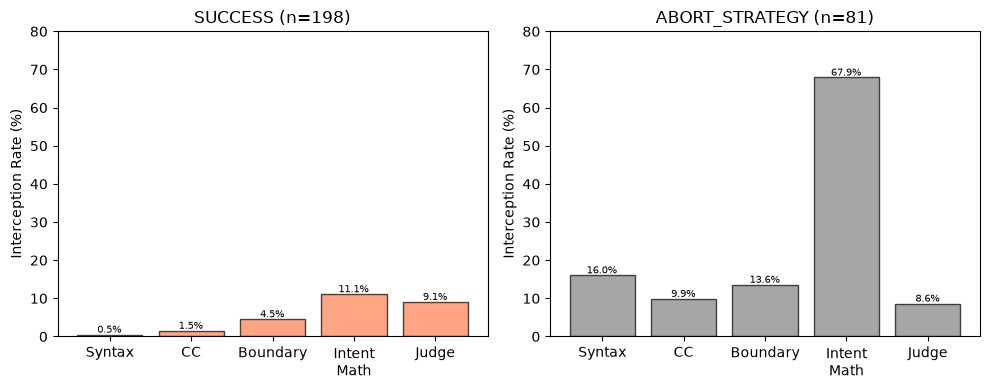

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels_short = ['Syntax', 'CC', 'Boundary', 'Intent\nMath', 'Judge']
for ax, es, color in zip(axes, ['SUCCESS', 'ABORT_STRATEGY'], ['coral', 'gray']):
    subset = multi[multi['exit_status'] == es]
    n = len(subset)
    pcts = []
    print(f"{es} (n={n}):")
    for i, c in enumerate(tier_cols):
        cnt = int((subset[c] > 0).sum())
        pct = cnt / n * 100
        pcts.append(pct)
        print(f"  {c}: {cnt:4d} ({pct:.1f}%)")
    any_cnt = int(subset['any_tier'].sum())
    print(f"  any_tier: {any_cnt:4d} ({any_cnt/n*100:.1f}%)\n")
    bars = ax.bar(labels_short, pcts, color=color, alpha=0.7, edgecolor='black')
    for bar, p in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{p:.1f}%', ha='center', fontsize=7)
    ax.set_title(f'{es} (n={n})')
    ax.set_ylabel('Interception Rate (%)')
    ax.set_ylim(0, 80)
plt.tight_layout()
plt.savefig('charts/tier/tier_interception_by_exit.png', dpi=100)
plt.show()


# Interception Rate by Difficulty — SUCCESS Only


Interception Rate by Difficulty (SUCCESS-Only, any_tier):
  Easy (n=54):
    tier1_syntax:   1/54 = 1.9%
    tier2a_cc:   0/54 = 0.0%
    tier2b_boundary:   2/54 = 3.7%
    tier2c_intent_math:   5/54 = 9.3%
    tier3_judge:   4/54 = 7.4%
    ANY:  11/54 = 20.4%

  Medium (n=104):
    tier1_syntax:   0/104 = 0.0%
    tier2a_cc:   2/104 = 1.9%
    tier2b_boundary:   5/104 = 4.8%
    tier2c_intent_math:  12/104 = 11.5%
    tier3_judge:   9/104 = 8.7%
    ANY:  24/104 = 23.1%

  Hard (n=40):
    tier1_syntax:   0/40 = 0.0%
    tier2a_cc:   1/40 = 2.5%
    tier2b_boundary:   2/40 = 5.0%
    tier2c_intent_math:   5/40 = 12.5%
    tier3_judge:   5/40 = 12.5%
    ANY:  11/40 = 27.5%



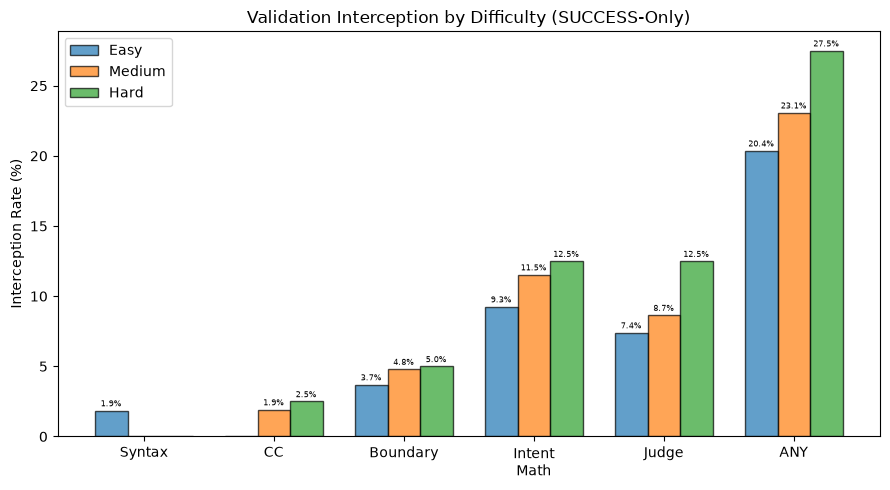

In [5]:
succ = multi[multi['exit_status'] == 'SUCCESS']
diffs = ['Easy', 'Medium', 'Hard']
tier_short = ['Syntax', 'CC', 'Boundary', 'Intent\nMath', 'Judge']

print(f"Interception Rate by Difficulty (SUCCESS-Only, any_tier):")
diff_data = {}
for diff in diffs:
    sub = succ[succ['difficulty'] == diff]
    n = len(sub)
    pcts = []
    print(f"  {diff} (n={n}):")
    for c in tier_cols:
        cnt = int((sub[c] > 0).sum())
        pct = cnt / n * 100
        pcts.append(pct)
        print(f"    {c}: {cnt:3d}/{n} = {pct:.1f}%")
    any_cnt = int(sub['any_tier'].sum())
    pcts.append(any_cnt / n * 100)
    print(f"    ANY: {any_cnt:3d}/{n} = {any_cnt/n*100:.1f}%\n")
    diff_data[diff] = pcts

labels_full = tier_short + ['ANY']
x = np.arange(len(labels_full))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, (diff, pcts) in enumerate(diff_data.items()):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, pcts, width, label=diff, alpha=0.7, edgecolor='black')
    for bar, p in zip(bars, pcts):
        if p > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{p:.1f}%', ha='center', fontsize=6)
ax.set_title('Validation Interception by Difficulty (SUCCESS-Only)')
ax.set_ylabel('Interception Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(labels_full)
ax.legend()
plt.tight_layout()
plt.savefig('charts/tier/tier_interception_by_difficulty.png', dpi=100)
plt.show()


# Interception Rate by Intent — SUCCESS Only


Interception Rate by Intent (SUCCESS-Only, any_tier):
  EXTRACT_METHOD                 (n=42): ANY=7.1%
    intent_math=4.8%, judge=2.4%, syntax=0.0%
  INLINE_VARIABLE                (n=16): ANY=12.5%
    intent_math=0.0%, judge=12.5%, syntax=0.0%
  FLATTEN_CONDITIONAL            (n= 5): ANY=20.0%
    intent_math=0.0%, judge=0.0%, syntax=20.0%
  RENAME_SYMBOL                  (n=36): ANY=22.2%
    intent_math=11.1%, judge=13.9%, syntax=0.0%
  REPLACE_LOOP_WITH_PIPELINE     (n=16): ANY=25.0%
    intent_math=6.2%, judge=18.8%, syntax=0.0%
  EXTRACT_CONSTANT               (n= 8): ANY=25.0%
    intent_math=12.5%, judge=0.0%, syntax=0.0%
  DECOMPOSE_CONDITIONAL          (n=44): ANY=29.5%
    intent_math=11.4%, judge=13.6%, syntax=0.0%
  INLINE_METHOD                  (n=12): ANY=33.3%
    intent_math=0.0%, judge=8.3%, syntax=0.0%
  CONSOLIDATE_CONDITIONAL        (n= 5): ANY=40.0%
    intent_math=40.0%, judge=0.0%, syntax=0.0%
  REMOVE_CONTROL_FLAG            (n= 6): ANY=50.0%
    intent_mat

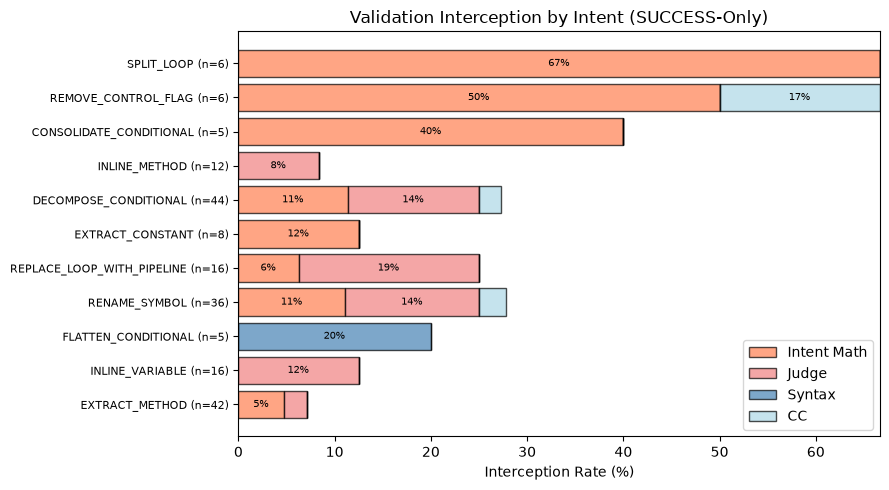

In [6]:
intent_data = []
for intent, sub in succ.groupby('intent'):
    n = len(sub)
    if n < 3:
        continue
    row = {'intent': intent, 'n': n}
    row['any_pct'] = sub['any_tier'].sum() / n * 100
    row['intent_math_pct'] = (sub['tier2c_intent_math'] > 0).sum() / n * 100
    row['judge_pct'] = (sub['tier3_judge'] > 0).sum() / n * 100
    row['syntax_pct'] = (sub['tier1_syntax'] > 0).sum() / n * 100
    row['cc_pct'] = (sub['tier2a_cc'] > 0).sum() / n * 100
    row['boundary_pct'] = (sub['tier2b_boundary'] > 0).sum() / n * 100
    intent_data.append(row)

df_intent = pd.DataFrame(intent_data).sort_values('any_pct', ascending=True)
print(f"Interception Rate by Intent (SUCCESS-Only, any_tier):")
for _, r in df_intent.iterrows():
    print(f"  {r['intent']:30s} (n={int(r['n']):2d}): ANY={r['any_pct']:.1f}%")
    print(f"    intent_math={r['intent_math_pct']:.1f}%, judge={r['judge_pct']:.1f}%, syntax={r['syntax_pct']:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(df_intent))
stack_cols = ['intent_math_pct', 'judge_pct', 'syntax_pct', 'cc_pct']
stack_labels = ['Intent Math', 'Judge', 'Syntax', 'CC']
stack_colors = ['coral', 'lightcoral', 'steelblue', 'lightblue']
left = np.zeros(len(df_intent))
for col, label, color in zip(stack_cols, stack_labels, stack_colors):
    vals = df_intent[col].values
    bars = ax.barh(y_pos, vals, left=left, label=label, color=color, alpha=0.7, edgecolor='black')
    for i, v in enumerate(vals):
        if v > 3:
            ax.text(left[i] + v/2, y_pos[i], f'{v:.0f}%', ha='center', va='center', fontsize=7)
    left += vals
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r['intent']} (n={int(r['n'])})" for _, r in df_intent.iterrows()], fontsize=8)
ax.set_xlabel('Interception Rate (%)')
ax.set_title('Validation Interception by Intent (SUCCESS-Only)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/tier/tier_interception_by_intent.png', dpi=100)
plt.show()


#### Summary

**Overall (RAW)**: 45.5% of multi-agent runs trigger at least one validation tier. The dominant detection gate is `tier2c_intent_math` (27.6%), which checks whether the refactoring preserved the intended structural transformation. This tier is the primary abort trigger: 67.9% of ABORT_STRATEGY exits are caught by intent-math.

**By Difficulty (SUCCESS-Only)**: Hard tasks show the highest ANY interception (27.5%), followed by Medium (23.1%) and Easy (20.4%). Intent-math and judge rejections rise with difficulty, reflecting the increasing challenge of intent preservation on complex transformations.

**By Intent (SUCCESS-Only)**: SPLIT_LOOP (66.7%), REMOVE_CONTROL_FLAG (50.0%), and CONSOLIDATE_CONDITIONAL (40.0%) have the highest interception rates — these intents involve structural code changes the validator frequently flags. EXTRACT_METHOD (7.1%) and INLINE_VARIABLE (12.5%) have the lowest interception — these well-scoped transformations rarely trigger validation errors.

**SUCCESS-Only (n=198)**: 15.2% of successful runs had non-fatal tier issues — detected but the run still completed. Most were intent-math flags (11.1%) or judge rejections (9.1%) that were eventually resolved or overridden.

**Interpretation**: The multi-agent validation pipeline acts as a deterministic safety net. The intent-match checker is the most active gate, catching 27.6% of all runs and 67.9% of aborted runs. Interception rates vary significantly by intent type, with structural transformations (split loops, control flag removal) being disproportionately flagged.
